#### Get the landuse layer data from https://data.gov.sg/datasets?query=masterplan+land+use&resultId=2107

Convert the downloaded geojson file to gpkg for better compatibility with qgis.

```
ogr2ogr -f GPKG -nlt MULTIPOLYGON masterplan2019landuselayer.gpkg MasterPlan2019LandUselayer.geojson
```

Create a new database in sql to work with the gpkg files and add the postgis extensions
```
psql -U <username> -d template1

CREATE DATABASE landuse;

\connect landuse

CREATE EXTENSION postgis;
CREATE EXTENSION postgis_topology;
```

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import seaborn as sns
import os
import matplotlib.pyplot as plt

In [2]:
CURRENT_DIRECTORY =  os.getcwd()
SRC_DIRECTORY = Path(CURRENT_DIRECTORY).parents[1]
print(SRC_DIRECTORY)

BASE_DATASET_PATH = Path(SRC_DIRECTORY).parents[0]
BASE_DATASET_PATH = BASE_DATASET_PATH / "datasets"
print(BASE_DATASET_PATH)

/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/src
/Users/yitong/Desktop/Uni_Skool/Y3 Internship SingHealth/code/Mobile-AED-Study/datasets


In [3]:
# read the gpkg file
landuse_2019 = Path(BASE_DATASET_PATH / "singapore_data/data_gov/masterplan_2019/masterplan2019landuselayer.gpkg")

landuse_layer_2019 = gpd.read_file(landuse_2019)

In [4]:
landuse_layer_2019.columns

Index(['OBJECTID', 'LU_DESC', 'LU_TEXT', 'GPR', 'WHI_Q_MX', 'GPR_B_MN',
       'INC_CRC', 'FMEL_UPD_D', 'SHAPE.AREA', 'SHAPE.LEN', 'geometry'],
      dtype='object')

#### If the landuse file is SHP folder, need to unzip the SHP folder first and convert it to gpkg file

eg: ogr2ogr -f GPKG masterplan2014landuselayer.gpkg MasterPlan2014LandUse/Master\ Plan\ 2014\ Land\ Use\ \(SHP\) -nlt PROMOTE_TO_MULTI

In [5]:
def combine_landuse_subzone_tables(year):
    print(f"""
    ogr2ogr -f GPKG masterplan{year}landuselayer_3414.gpkg masterplan{year}landuselayer.gpkg \
    -t_srs EPSG:3414
    ogr2ogr -f GPKG subzone_boundary_{year}_3414.gpkg subzone_boundary_{year}.gpkg \
    -t_srs EPSG:3414
    """)

    year_for_layer = str(year)[2:]
    # print(year_for_layer)

    print(f"""
    ogr2ogr -f PostgreSQL \
    PG:"dbname=landuse user=yitong" \
    masterplan{year}landuselayer_3414.gpkg \
    -nln landuse_{year} \
    -lco GEOMETRY_NAME=geom \
    -lco FID=id \
    -nlt PROMOTE_TO_MULTI \
    G_MP{year_for_layer}_LAND_USE_PL

## for 2014
    ogr2ogr -f PostgreSQL \
    PG:"dbname=landuse user=yitong" \
    subzone_boundary_{year}_3414.gpkg \
    -nln subzone_{year} \
    -lco GEOMETRY_NAME=geom \
    -lco FID=id \
    -nlt PROMOTE_TO_MULTI \
    MP{year_for_layer}_SUBZONE_NO_SEA_PL

## for 2019
    ogr2ogr -f PostgreSQL \
    PG:"dbname=landuse user=yitong" \
    subzone_boundary_{year}_3414.gpkg \
    -nln subzone_{year} \
    -lco GEOMETRY_NAME=geom \
    -lco FID=id \
    -nlt PROMOTE_TO_MULTI \
    subzone
    """)

    print(f"""
    UPDATE landuse_{year}
    SET geom = ST_CollectionExtract(ST_MakeValid(geom), 3)::geometry(MultiPolygon, 3414)
    WHERE NOT ST_IsValid(geom);

    UPDATE subzone_{year}
    SET geom = ST_CollectionExtract(ST_MakeValid(geom), 3)::geometry(MultiPolygon, 3414)
    WHERE NOT ST_IsValid(geom);
    """)

    print(f""""
    DROP TABLE IF EXISTS landuse_by_subzone_{year};
    CREATE TABLE landuse_by_subzone_{year} AS
    SELECT
        lu.LU_DESC,
        
        sz.SUBZONE_N,
        sz.PLN_AREA_N,
        
        ST_Area(
            ST_Intersection(lu.geom, sz.geom)
        ) AS area_m2,
        
        ST_Intersection(lu.geom, sz.geom) AS geometry

    FROM landuse_{year} lu 

    -- An INNER JOIN ensures that only land use polygons that overlap with a subzone are included.
    INNER JOIN subzone_{year} sz
        ON ST_Intersects(lu.geom, sz.geom);      
    """)
    

In [6]:
combine_landuse_subzone_tables(2008)


    ogr2ogr -f GPKG masterplan2008landuselayer_3414.gpkg masterplan2008landuselayer.gpkg     -t_srs EPSG:3414
    ogr2ogr -f GPKG subzone_boundary_2008_3414.gpkg subzone_boundary_2008.gpkg     -t_srs EPSG:3414
    

    ogr2ogr -f PostgreSQL     PG:"dbname=landuse user=yitong"     masterplan2008landuselayer_3414.gpkg     -nln landuse_2008     -lco GEOMETRY_NAME=geom     -lco FID=id     -nlt PROMOTE_TO_MULTI     G_MP08_LAND_USE_PL

## for 2014
    ogr2ogr -f PostgreSQL     PG:"dbname=landuse user=yitong"     subzone_boundary_2008_3414.gpkg     -nln subzone_2008     -lco GEOMETRY_NAME=geom     -lco FID=id     -nlt PROMOTE_TO_MULTI     MP08_SUBZONE_NO_SEA_PL

## for 2019
    ogr2ogr -f PostgreSQL     PG:"dbname=landuse user=yitong"     subzone_boundary_2008_3414.gpkg     -nln subzone_2008     -lco GEOMETRY_NAME=geom     -lco FID=id     -nlt PROMOTE_TO_MULTI     subzone
    

    UPDATE landuse_2008
    SET geom = ST_CollectionExtract(ST_MakeValid(geom), 3)::geometry(MultiPolygon, 3414)
 

In [7]:
def get_landuse_area_per_subzone(year):

    print(f"""
    DROP TABLE IF EXISTS subzone_summary_dynamic_{year};
    DO $$
    DECLARE
        sql_query TEXT;
        column_list TEXT;
    BEGIN
        -- 1. Generate the SUM(CASE...) columns
        SELECT string_agg(
            format('SUM(CASE WHEN lu_desc = %L THEN area_m2 ELSE 0 END) AS %I', 
                lu_desc, 
                lower(replace(lu_desc, ' ', '_'))), 
            ', '
        )
        INTO column_list
        FROM (SELECT DISTINCT lu_desc FROM landuse_by_subzone_{year}) AS unique_lu;

        -- 2. Construct the query with a Subquery to find the Max
        -- We use DISTINCT ON to find the lu_desc that has the maximum area per subzone
        sql_query := 'CREATE TABLE subzone_summary_dynamic_{year} AS 
                    WITH base_sums AS (
                        SELECT subzone_n, pln_area_n, ' || column_list || ' 
                        FROM landuse_by_subzone_{year} 
                        GROUP BY subzone_n, pln_area_n
                    ),
                    primary_class AS (
                        SELECT DISTINCT ON (subzone_n, pln_area_n)
                            subzone_n, pln_area_n, lu_desc as pri_classification
                        FROM (
                            SELECT subzone_n, pln_area_n, lu_desc, SUM(area_m2) as total_lu_area
                            FROM landuse_by_subzone_{year}
                            GROUP BY subzone_n, pln_area_n, lu_desc
                        ) AS sub
                        ORDER BY subzone_n, pln_area_n, total_lu_area DESC
                    )
                    SELECT b.*, p.pri_classification
                    FROM base_sums b
                    JOIN primary_class p ON b.subzone_n = p.subzone_n AND b.pln_area_n = p.pln_area_n
                    ORDER BY b.pln_area_n, b.subzone_n';

        EXECUTE sql_query;
    END $$;


    ogr2ogr -f CSV subzone_classifications_{year}.csv \
    PG:"dbname=landuse user=yitong" subzone_summary_dynamic_{year}
    """)

In [8]:
get_landuse_area_per_subzone(2014)


    DROP TABLE IF EXISTS subzone_summary_dynamic_2014;
    DO $$
    DECLARE
        sql_query TEXT;
        column_list TEXT;
    BEGIN
        -- 1. Generate the SUM(CASE...) columns
        SELECT string_agg(
            format('SUM(CASE WHEN lu_desc = %L THEN area_m2 ELSE 0 END) AS %I', 
                lu_desc, 
                lower(replace(lu_desc, ' ', '_'))), 
            ', '
        )
        INTO column_list
        FROM (SELECT DISTINCT lu_desc FROM landuse_by_subzone_2014) AS unique_lu;

        -- 2. Construct the query with a Subquery to find the Max
        -- We use DISTINCT ON to find the lu_desc that has the maximum area per subzone
        sql_query := 'CREATE TABLE subzone_summary_dynamic_2014 AS 
                    WITH base_sums AS (
                        SELECT subzone_n, pln_area_n, ' || column_list || ' 
                        FROM landuse_by_subzone_2014 
                        GROUP BY subzone_n, pln_area_n
                    ),
                    p

#### add the landuse gpkg and subzone boundary gpkg files to sql database

convert the gpkg to EPSG 3414 first
```
ogr2ogr -f GPKG masterplan2019landuselayer_3414.gpkg masterplan2019landuselayer.gpkg \
  -t_srs EPSG:3414
ogr2ogr -f GPKG subzone_boundary_2019_3414.gpkg subzone_boundary_2019.gpkg \
  -t_srs EPSG:3414
```

```
ogr2ogr -f PostgreSQL \
  PG:"dbname=landuse user=yitong" \
  masterplan2019landuselayer_3414.gpkg \
  -nln landuse_2019 \
  -lco GEOMETRY_NAME=geom \
  -lco FID=id \
  -nlt PROMOTE_TO_MULTI \
  G_MP19_LAND_USE_PL

ogr2ogr -f PostgreSQL \
  PG:"dbname=landuse user=yitong" \
  subzone_boundary_2019_3414.gpkg \
  -nln subzone_2019 \
  -lco GEOMETRY_NAME=geom \
  -lco FID=id \
  -nlt PROMOTE_TO_MULTI \
  subzone

UPDATE landuse_2019
SET geom = ST_CollectionExtract(ST_MakeValid(geom), 3)::geometry(MultiPolygon, 3414)
WHERE NOT ST_IsValid(geom);

UPDATE subzone_2019
SET geom = ST_CollectionExtract(ST_MakeValid(geom), 3)::geometry(MultiPolygon, 3414)
WHERE NOT ST_IsValid(geom);
```

```
DROP TABLE IF EXISTS landuse_by_subzone_2019;
CREATE TABLE landuse_by_subzone_2019 AS
SELECT
    lu.LU_DESC,
    
    sz.SUBZONE_N,
    sz.PLN_AREA_N,
    
    ST_Area(
        ST_Intersection(lu.geom, sz.geom)
    ) AS area_m2,
    
    ST_Intersection(lu.geom, sz.geom) AS geometry

FROM landuse_2019 lu 

-- An INNER JOIN ensures that only land use polygons that overlap with a subzone are included.
INNER JOIN subzone_2019 sz
    ON ST_Intersects(lu.geom, sz.geom);
```

Get the output table
```
ogr2ogr -f GPKG landuse_by_subzone_2019.gpkg \
PG:"dbname=landuse user=yitong" landuse_by_subzone_2019
```

#### Calculate the area of each landuse types in each subzone and find the primary classifcation (largest landuse area in the subzone)
```
DROP TABLE IF EXISTS subzone_summary_dynamic_2019;
DO $$
DECLARE
    sql_query TEXT;
    column_list TEXT;
BEGIN
    -- 1. Generate the SUM(CASE...) columns
    SELECT string_agg(
        format('SUM(CASE WHEN lu_desc = %L THEN area_m2 ELSE 0 END) AS %I', 
               lu_desc, 
               lower(replace(lu_desc, ' ', '_'))), 
        ', '
    )
    INTO column_list
    FROM (SELECT DISTINCT lu_desc FROM landuse_by_subzone_2019) AS unique_lu;

    -- 2. Construct the query with a Subquery to find the Max
    -- We use DISTINCT ON to find the lu_desc that has the maximum area per subzone
    sql_query := 'CREATE TABLE subzone_summary_dynamic_2019 AS 
                  WITH base_sums AS (
                      SELECT subzone_n, pln_area_n, ' || column_list || ' 
                      FROM landuse_by_subzone_2019 
                      GROUP BY subzone_n, pln_area_n
                  ),
                  primary_class AS (
                      SELECT DISTINCT ON (subzone_n, pln_area_n)
                          subzone_n, pln_area_n, lu_desc as pri_classification
                      FROM (
                          SELECT subzone_n, pln_area_n, lu_desc, SUM(area_m2) as total_lu_area
                          FROM landuse_by_subzone_2019
                          GROUP BY subzone_n, pln_area_n, lu_desc
                      ) AS sub
                      ORDER BY subzone_n, pln_area_n, total_lu_area DESC
                  )
                  SELECT b.*, p.pri_classification
                  FROM base_sums b
                  JOIN primary_class p ON b.subzone_n = p.subzone_n AND b.pln_area_n = p.pln_area_n
                  ORDER BY b.pln_area_n, b.subzone_n';

    EXECUTE sql_query;
END $$;


ogr2ogr -f CSV subzone_classifications_2019.csv \
PG:"dbname=landuse user=yitong" subzone_summary_dynamic_2019
```

In [9]:
def cleaning_up(year):
    print(f"""
    rm -f masterplan{year}landuselayer_3414.gpkg subzone_boundary_{year}_3414.gpkg
    """)


In [10]:
cleaning_up(2014)


    rm -f masterplan2014landuselayer_3414.gpkg subzone_boundary_2014_3414.gpkg
    


In [3]:
filepath = Path(BASE_DATASET_PATH / "singapore_data/data_gov/masterplan_2014/subzone_classifications_2014.csv")

subzone_classification_df = pd.read_csv(filepath)

In [4]:
subzone_classification_df.columns

Index(['subzone_n', 'pln_area_n', 'beach_area', 'business_2',
       'educational_institution', 'utility', 'special_use', 'waterbody',
       'port_/_airport', 'park', 'road', 'business_1_-_white', 'commercial',
       'light_rapid_transit', 'transport_facilities', 'health_&_medical_care',
       'business_1', 'residential', 'sports_&_recreation',
       'commercial_&_residential', 'mass_rapid_transit',
       'civic_&_community_institution', 'open_space',
       'residential_with_commercial_at_1st_storey', 'cemetery', 'reserve_site',
       'white', 'place_of_worship', 'business_2_-_white', 'hotel',
       'residential_/_institution', 'business_park_-_white', 'business_park',
       'agriculture', 'pri_classification'],
      dtype='object')

In [5]:
residential_cols = [col for col in subzone_classification_df.columns if 'residential' in col]
display(residential_cols)

workplace_cols = [col for col in subzone_classification_df.columns if 'business' in col]
display(workplace_cols)

['residential',
 'commercial_&_residential',
 'residential_with_commercial_at_1st_storey',
 'residential_/_institution']

['business_2',
 'business_1_-_white',
 'business_1',
 'business_2_-_white',
 'business_park_-_white',
 'business_park']

In [6]:
# find the sum of residential and workplace areas for each subzone
subzone_classification_df['total_residential_area'] = subzone_classification_df[residential_cols].sum(axis=1)

subzone_classification_df["total_workplace_area"] = subzone_classification_df[workplace_cols].sum(axis=1)

df_resident = subzone_classification_df.sort_values(by = "total_residential_area", ascending = False)

df_workplace = subzone_classification_df.sort_values(by = "total_workplace_area", ascending = False)

display(df_resident[["subzone_n", "pln_area_n", "pri_classification", "total_residential_area", "total_workplace_area"]])
display(df_workplace[["subzone_n", "pln_area_n", "pri_classification", "total_residential_area", "total_workplace_area"]])

,subzone_n,pln_area_n,pri_classification,total_residential_area,total_workplace_area
282,TENGAH,TENGAH,RESIDENTIAL,5.682580e+06,1.221744e+06
66,SWISS CLUB,BUKIT TIMAH,RESIDENTIAL,2.715092e+06,0.000000e+00
16,FRANKEL,BEDOK,RESIDENTIAL,2.641409e+06,3.715032e+05
274,TAMPINES EAST,TAMPINES,RESIDENTIAL,2.562032e+06,0.000000e+00
64,HOLLAND ROAD,BUKIT TIMAH,RESIDENTIAL,2.537321e+06,0.000000e+00
...,...,...,...,...,...
266,SOUTHERN GROUP,SOUTHERN ISLANDS,SPORTS & RECREATION,0.000000e+00,0.000000e+00
146,MANDAI WEST,MANDAI,OPEN SPACE,0.000000e+00,0.000000e+00
102,KALLANG WAY,GEYLANG,BUSINESS 1,0.000000e+00,6.994461e+05
223,KAMPONG GLAM,ROCHOR,COMMERCIAL,0.000000e+00,0.000000e+00


,subzone_n,pln_area_n,pri_classification,total_residential_area,total_workplace_area
301,JURONG ISLAND AND BUKOM,WESTERN ISLANDS,BUSINESS 2,0.000000,3.338295e+07
300,TUAS VIEW EXTENSION,TUAS,PORT / AIRPORT,0.000000,9.679066e+06
299,TUAS VIEW,TUAS,BUSINESS 2,0.000000,4.274842e+06
182,PASIR RIS WAFER FAB PARK,PASIR RIS,BUSINESS 2,0.000000,3.200142e+06
191,GUL CIRCLE,PIONEER,BUSINESS 2,0.000000,2.715121e+06
...,...,...,...,...,...
140,KAMPONG JAVA,KALLANG,RESIDENTIAL,472073.175352,0.000000e+00
141,LAVENDER,KALLANG,ROAD,257241.689772,0.000000e+00
142,TANJONG RHU,KALLANG,SPORTS & RECREATION,519227.614597,0.000000e+00
143,LIM CHU KANG,LIM CHU KANG,AGRICULTURE,0.000000,0.000000e+00


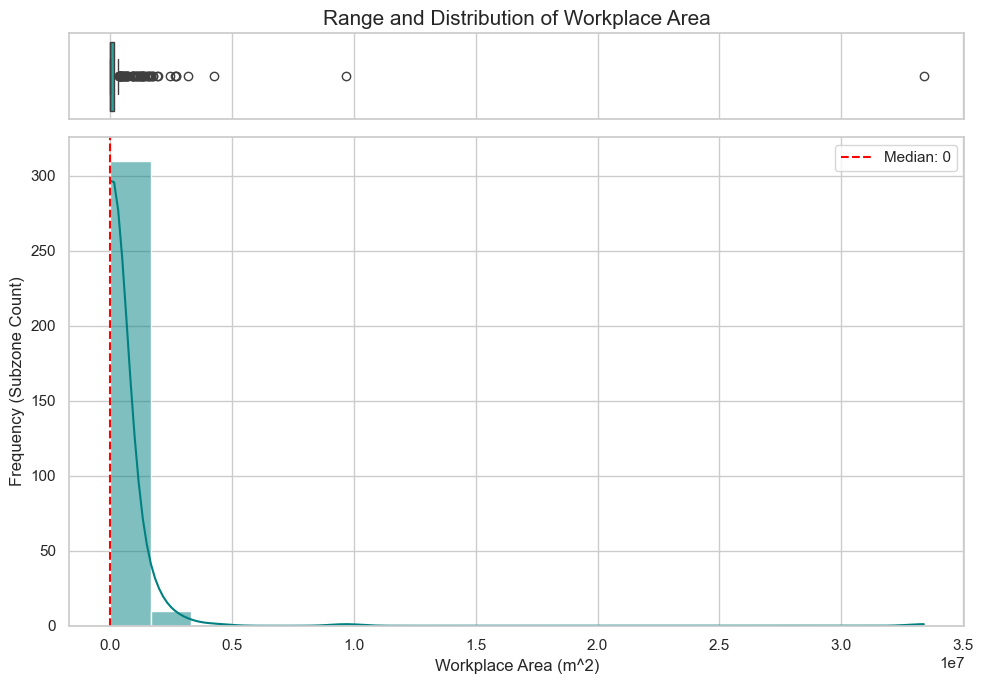

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (1 row, 2 columns - or stacked)
# We will use a "Gridspec" style approach for a top-bottom view
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 7))

# 1. Plot the Range (Boxplot) on the top axis
sns.boxplot(x=subzone_classification_df["total_workplace_area"], ax=ax_box, color="lightseagreen")
ax_box.set(xlabel='') # Hide xlabel for the top plot
ax_box.set_title('Range and Distribution of Workplace Area', fontsize=15)

# 2. Plot the Distribution (Histogram + KDE) on the bottom axis
sns.histplot(subzone_classification_df["total_workplace_area"], ax=ax_hist, kde=True, color="teal", bins=20)

# Labeling
plt.xlabel('Workplace Area (m^2)', fontsize=12)
plt.ylabel('Frequency (Subzone Count)', fontsize=12)

# Add a vertical line for the Median on the histogram
median_val = subzone_classification_df["total_workplace_area"].median()
ax_hist.axvline(median_val, color='red', linestyle='--', label=f'Median: {median_val:,.0f}')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
save_filepath = Path(BASE_DATASET_PATH / "singapore_data/data_gov/masterplan_2014/subzone_classifications_2014_edited.csv")

subzone_classification_df.to_csv(save_filepath, index = False)